# RAMA Adaptive Safety Validation on rel-avito/ad-ctr

**Extreme-Cardinality Stress Test for Rank-Aware Moment Aggregation**

This notebook demonstrates **RAMA (Rank-Aware Moment Aggregation)**, a novel graph neural network aggregation method that learns a diversity gate controlling variance injection based on neighborhood cardinality and effective rank.

**Key findings from the experiment:**
- RAMA avoids catastrophic failure on extreme-cardinality edges (mean FK cardinality 114,625)
- R² stays above -1.0 on average (vs PRMP's R²=-5046), validating the adaptive safety mechanism
- Baseline MAE: 0.0503±0.0108, RAMA MAE: 0.0672±0.0236 — RAMA is ~34% worse but not catastrophically so
- Cohen's d = 0.82 (large effect favoring baseline), confirming RAMA gracefully degrades

The notebook: (1) implements RAMA as a standalone PyTorch module, (2) tests it on synthetic data, (3) loads pre-computed experiment results, (4) re-runs the statistical analysis, and (5) visualizes the comparison.

In [1]:
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# All packages used are pre-installed on Colab; install locally to match Colab env
if 'google.colab' not in sys.modules:
    # Colab versions: numpy==2.0.2, scipy==1.16.3, torch==2.9.0
    # For Python <3.11, use latest compatible scipy instead
    _v = sys.version_info
    _scipy_ver = 'scipy==1.16.3' if _v >= (3, 11) else 'scipy==1.15.3'
    _pip('numpy==2.0.2', 'pandas==2.2.2', 'scikit-learn==1.6.1',
         _scipy_ver, 'matplotlib==3.10.0')

# Try importing torch; if unavailable, use numpy-only fallback
try:
    import torch
    import torch.nn as nn
    import torch.nn.functional as F
    HAS_TORCH = True
    print(f"PyTorch available: {torch.__version__}")
except ImportError:
    HAS_TORCH = False
    print("PyTorch not available -- using NumPy-only RAMA demo")

PyTorch not available -- using NumPy-only RAMA demo



[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: python3 -m pip install --upgrade pip


In [2]:
import json
import math
import os
import warnings
import copy
import time

import numpy as np
import pandas as pd
import scipy.stats as stats
from sklearn.metrics import mean_absolute_error, r2_score, root_mean_squared_error
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

print(f"NumPy version: {np.__version__}")
print(f"Torch available: {HAS_TORCH}")

NumPy version: 2.0.2
Torch available: False


In [3]:
GITHUB_DATA_URL = "https://raw.githubusercontent.com/ai-inventor-papers/ai-invention-9b0386-rank-aware-moment-aggregation-diversity-/main/experiment_iter3_rama_adaptive_s/demo/mini_demo_data.json"

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception: pass
    if os.path.exists("mini_demo_data.json"):
        with open("mini_demo_data.json") as f: return json.load(f)
    raise FileNotFoundError("Could not load mini_demo_data.json")

In [4]:
data = load_data()
print(f"Loaded experiment data: {data['metadata']['method_name']}")
print(f"Dataset: {data['metadata']['dataset']}, Task: {data['metadata']['task']}")
print(f"Seeds: {data['metadata']['seeds']}")
print(f"Number of examples: {len(data['datasets'][0]['examples'])}")

Loaded experiment data: RAMA (Rank-Aware Moment Aggregation)
Dataset: rel-avito, Task: ad-ctr
Seeds: [42, 123, 456, 789, 1024]
Number of examples: 5


## Configuration

Tunable parameters for the RAMA synthetic demo. These control the standalone forward-pass test (not the full training which requires the rel-avito dataset).

In [5]:
# --- RAMA module parameters ---
CHANNELS = 64          # Embedding dimension (original: 64)
GATE_HIDDEN = 16       # Gate MLP hidden size (original: 16)
EPS = 1e-6             # Numerical stability epsilon

# --- Synthetic test parameters ---
N_NODES = 128          # Number of destination nodes (original experiment: thousands)
N_EDGES = 512          # Number of source messages (original: millions)
N_FORWARD_PASSES = 10  # Number of test forward passes (original: 20 batches for gate stats)

## SECTION 1: RAMA Aggregation Implementation

The core RAMA module. Learns a gate `g(log(N+1), rho)` that controls injection of variance information:

```
out = mu + g * W_sigma(var)
```

where `rho` is a variance-entropy proxy for effective rank. Zero-initialized so it starts as pure mean aggregation. This standalone version uses `torch.scatter_add` instead of PyG's `Aggregation` base class.

In [6]:
if HAS_TORCH:
    class RAMAAggregation(nn.Module):
        """Rank-Aware Moment Aggregation (standalone PyTorch version)."""
        def __init__(self, channels, gate_hidden=16, eps=1e-6):
            super().__init__()
            self.channels = channels
            self.eps = eps
            self.W_sigma = nn.Linear(channels, channels, bias=False)
            self.W_g = nn.Linear(2, gate_hidden)
            self.gate_out = nn.Linear(gate_hidden, channels)
            self._last_gate_values = None
            self._last_N_values = None
            self._last_rho_values = None
            self._record_gates = False
            nn.init.zeros_(self.W_sigma.weight)
            nn.init.zeros_(self.gate_out.weight)
            nn.init.zeros_(self.gate_out.bias)
            nn.init.xavier_uniform_(self.W_g.weight)
            nn.init.zeros_(self.W_g.bias)

        def _scatter_mean(self, x, index, dim_size):
            out_sum = torch.zeros(dim_size, x.size(1), device=x.device, dtype=x.dtype)
            out_count = torch.zeros(dim_size, 1, device=x.device, dtype=x.dtype)
            out_sum.scatter_add_(0, index.unsqueeze(1).expand_as(x), x)
            ones = torch.ones(x.size(0), 1, device=x.device, dtype=x.dtype)
            out_count.scatter_add_(0, index.unsqueeze(1), ones)
            out_count = out_count.clamp(min=1)
            return out_sum / out_count, out_count

        def forward(self, x, index, dim_size):
            mu, N = self._scatter_mean(x, index, dim_size)
            mean_x2, _ = self._scatter_mean(x * x, index, dim_size)
            var = (mean_x2 - mu * mu).clamp(min=0)
            var = torch.nan_to_num(var, nan=0.0)
            var_sum = var.sum(dim=-1, keepdim=True).clamp(min=self.eps)
            p = (var / var_sum).clamp(min=self.eps)
            H = -(p * p.log()).sum(dim=-1, keepdim=True)
            rho = H / math.log(max(self.channels, 2))
            gate_input = torch.cat([torch.log1p(N), rho], dim=-1)
            g = torch.sigmoid(self.gate_out(F.relu(self.W_g(gate_input))))
            out = mu + g * self.W_sigma(var)
            if self._record_gates:
                self._last_gate_values = g.detach().cpu()
                self._last_N_values = N.detach().cpu()
                self._last_rho_values = rho.detach().cpu()
            return out
else:
    class RAMAAggregation:
        """Rank-Aware Moment Aggregation (NumPy-only version for demo)."""
        def __init__(self, channels, gate_hidden=16, eps=1e-6):
            self.channels = channels
            self.eps = eps
            # Zero-init weights (mimics PyTorch zero init)
            self.W_sigma = np.zeros((channels, channels))
            rng = np.random.RandomState(42)
            self.W_g = rng.randn(2, gate_hidden) * 0.1
            self.gate_out_w = np.zeros((gate_hidden, channels))
            self.gate_out_b = np.zeros(channels)
            self._last_gate_values = None
            self._last_N_values = None
            self._last_rho_values = None
            self._record_gates = False

        def forward(self, x, index, dim_size):
            # Scatter mean
            mu = np.zeros((dim_size, self.channels))
            N = np.zeros((dim_size, 1))
            for i in range(len(index)):
                mu[index[i]] += x[i]
                N[index[i]] += 1
            N = np.maximum(N, 1)
            mu /= N
            # Variance
            mean_x2 = np.zeros((dim_size, self.channels))
            for i in range(len(index)):
                mean_x2[index[i]] += x[i] ** 2
            mean_x2 /= N
            var = np.maximum(mean_x2 - mu ** 2, 0)
            # Effective rank proxy
            var_sum = np.maximum(var.sum(axis=-1, keepdims=True), self.eps)
            p = np.maximum(var / var_sum, self.eps)
            H = -(p * np.log(p)).sum(axis=-1, keepdims=True)
            rho = H / math.log(max(self.channels, 2))
            # Gate
            gate_input = np.concatenate([np.log1p(N), rho], axis=-1)
            hidden = np.maximum(gate_input @ self.W_g, 0)  # ReLU
            g = 1.0 / (1.0 + np.exp(-(hidden @ self.gate_out_w + self.gate_out_b)))  # sigmoid
            out = mu + g * (var @ self.W_sigma)
            if self._record_gates:
                self._last_gate_values = g
                self._last_N_values = N
                self._last_rho_values = rho
            return out

print(f"RAMAAggregation defined ({'PyTorch' if HAS_TORCH else 'NumPy'} backend)")
print(f"Config: {CHANNELS} channels, {GATE_HIDDEN} gate hidden units")

RAMAAggregation defined (NumPy backend)
Config: 64 channels, 16 gate hidden units


## SECTION 2: Synthetic RAMA Forward Pass Test

Verify the RAMA module works correctly by running it on synthetic graph data with varying neighborhood cardinalities. We test that:
1. The zero-initialized gate produces output close to pure mean aggregation
2. Gate values and neighborhood statistics are recorded properly

In [7]:
np.random.seed(42)

# Create synthetic graph: N_EDGES source nodes mapped to N_NODES destinations
rama_module = RAMAAggregation(channels=CHANNELS, gate_hidden=GATE_HIDDEN, eps=EPS)
rama_module._record_gates = True

if HAS_TORCH:
    torch.manual_seed(42)
    x = torch.randn(N_EDGES, CHANNELS)
    index = torch.randint(0, N_NODES, (N_EDGES,))
else:
    x = np.random.randn(N_EDGES, CHANNELS).astype(np.float32)
    index = np.random.randint(0, N_NODES, N_EDGES)

# Run forward passes and collect gate statistics
gate_records = []
for i in range(N_FORWARD_PASSES):
    if HAS_TORCH:
        x_i = torch.randn(N_EDGES, CHANNELS)
    else:
        x_i = np.random.randn(N_EDGES, CHANNELS).astype(np.float32)
    out = rama_module.forward(x_i, index, dim_size=N_NODES)
    g = rama_module._last_gate_values
    N_vals = rama_module._last_N_values
    rho_vals = rama_module._last_rho_values
    if g is not None:
        if HAS_TORCH:
            g_np, N_np, rho_np = g.numpy(), N_vals.numpy(), rho_vals.numpy()
        else:
            g_np, N_np, rho_np = g, N_vals, rho_vals
        gate_records.append({
            'gate_mean': float(g_np.mean()),
            'gate_std': float(g_np.std()),
            'N_mean': float(N_np.mean()),
            'N_max': float(N_np.max()),
            'rho_mean': float(rho_np.mean()),
        })
        if i == 0:
            out_shape = out.shape if HAS_TORCH else out.shape
            print(f"Output shape: {out_shape}")
            print(f"Gate values (mean): {g_np.mean():.4f}")
            print(f"Gate values should be ~0.5 (sigmoid(0) due to zero init)")

# Compare RAMA to pure mean aggregation
rama_out = rama_module.forward(x, index, dim_size=N_NODES)
if HAS_TORCH:
    rama_out_np = rama_out.detach().numpy()
    x_np, idx_np = x.numpy(), index.numpy()
else:
    rama_out_np = rama_out
    x_np, idx_np = x, index

mean_out = np.zeros((N_NODES, CHANNELS), dtype=np.float32)
cnt = np.zeros((N_NODES, 1), dtype=np.float32)
for i in range(len(idx_np)):
    mean_out[idx_np[i]] += x_np[i]
    cnt[idx_np[i]] += 1
cnt = np.maximum(cnt, 1)
mean_out /= cnt

diff = np.abs(rama_out_np - mean_out).mean()
print(f"\nRAMA vs Mean aggregation difference: {diff:.6f}")
print(f"(Close to 0 confirms zero-initialized gate starts as mean aggregation)")

Output shape: (128, 64)
Gate values (mean): 0.5000
Gate values should be ~0.5 (sigmoid(0) due to zero init)

RAMA vs Mean aggregation difference: 0.000000
(Close to 0 confirms zero-initialized gate starts as mean aggregation)


## SECTION 3: Statistical Analysis Functions

These functions from the original experiment compute Cohen's d effect size and full statistical comparisons between baseline (mean aggregation) and RAMA.

In [8]:
def cohens_d(group1, group2):
    """Compute Cohen's d with 95% CI."""
    n1, n2 = len(group1), len(group2)
    m1, m2 = np.mean(group1), np.mean(group2)
    s1, s2 = np.std(group1, ddof=1), np.std(group2, ddof=1)
    sp = np.sqrt(((n1 - 1) * s1**2 + (n2 - 1) * s2**2) / (n1 + n2 - 2))
    d = (m2 - m1) / max(sp, 1e-12)
    se_d = np.sqrt((n1 + n2) / (n1 * n2) + d**2 / (2 * (n1 + n2)))
    ci_lower = d - 1.96 * se_d
    ci_upper = d + 1.96 * se_d
    return float(d), float(ci_lower), float(ci_upper)


def statistical_comparison(baseline_vals, rama_vals, metric_name):
    """Full statistical comparison between baseline and RAMA."""
    d, ci_lo, ci_hi = cohens_d(baseline_vals, rama_vals)
    t_stat, p_val = stats.ttest_ind(rama_vals, baseline_vals)
    return {
        "metric": metric_name,
        "cohen_d": round(d, 4),
        "ci_lower": round(ci_lo, 4),
        "ci_upper": round(ci_hi, 4),
        "p_value": round(float(p_val), 6),
        "baseline_mean": round(float(np.mean(baseline_vals)), 6),
        "baseline_std": round(float(np.std(baseline_vals)), 6),
        "rama_mean": round(float(np.mean(rama_vals)), 6),
        "rama_std": round(float(np.std(rama_vals)), 6),
    }


def compute_metrics(y_true, y_pred):
    """Compute MAE, R², RMSE."""
    mae = float(mean_absolute_error(y_true, y_pred))
    r2 = float(r2_score(y_true, y_pred))
    rmse = float(root_mean_squared_error(y_true, y_pred))
    return {"mae": mae, "r2": r2, "rmse": rmse}

print("Statistical analysis functions defined.")

Statistical analysis functions defined.


## SECTION 4: Re-run Statistical Analysis on Pre-computed Results

Extract per-seed metrics from the loaded experiment data and re-run the statistical comparison functions to verify the reported results.

In [9]:
# Extract per-seed metrics from loaded data
results = data['metadata']['results']
baseline_metrics = results['baseline_mean']['per_seed']
rama_metrics = results['rama']['per_seed']

baseline_maes = [m['mae'] for m in baseline_metrics.values()]
baseline_r2s = [m['r2'] for m in baseline_metrics.values()]
baseline_rmses = [m['rmse'] for m in baseline_metrics.values()]

rama_maes = [m['mae'] for m in rama_metrics.values()]
rama_r2s = [m['r2'] for m in rama_metrics.values()]
rama_rmses = [m['rmse'] for m in rama_metrics.values()]

# Re-run statistical comparisons
mae_comparison = statistical_comparison(baseline_maes, rama_maes, "MAE")
r2_comparison = statistical_comparison(baseline_r2s, rama_r2s, "R²")

# Safety check (from original script)
baseline_mae_mean = float(np.mean(baseline_maes))
rama_mae_mean = float(np.mean(rama_maes))
mae_pct_diff = abs(rama_mae_mean - baseline_mae_mean) / max(baseline_mae_mean, 1e-12) * 100
r2_not_catastrophic = float(np.mean(rama_r2s)) > -1.0

print("=" * 60)
print("RESULTS SUMMARY (re-computed from loaded data)")
print("=" * 60)
print(f"  Baseline MAE: {baseline_mae_mean:.4f} ± {np.std(baseline_maes):.4f}")
print(f"  RAMA MAE:     {rama_mae_mean:.4f} ± {np.std(rama_maes):.4f}")
print(f"  MAE % diff:   {mae_pct_diff:.2f}%")
print(f"  MAE within 5%: {mae_pct_diff < 5.0}")
print(f"  R² not catastrophic (> -1.0): {r2_not_catastrophic}")
print(f"  Cohen's d (MAE): {mae_comparison['cohen_d']:.4f} [{mae_comparison['ci_lower']:.4f}, {mae_comparison['ci_upper']:.4f}]")
print(f"  Cohen's d (R²):  {r2_comparison['cohen_d']:.4f} [{r2_comparison['ci_lower']:.4f}, {r2_comparison['ci_upper']:.4f}]")
print(f"  p-value (MAE):   {mae_comparison['p_value']:.6f}")
print(f"  p-value (R²):    {r2_comparison['p_value']:.6f}")
print("=" * 60)

# Per-seed comparison table
print("\nPer-seed comparison:")
print(f"{'Seed':<8} {'Base MAE':<12} {'RAMA MAE':<12} {'Base R²':<12} {'RAMA R²':<12} {'Safe?':<6}")
print("-" * 62)
for seed in data['metadata']['seeds']:
    seed_str = str(seed)
    bm = baseline_metrics[seed_str]
    rm = rama_metrics[seed_str]
    safe = "Yes" if rm['r2'] > -1.0 else "No"
    print(f"{seed:<8} {bm['mae']:<12.4f} {rm['mae']:<12.4f} {bm['r2']:<12.4f} {rm['r2']:<12.4f} {safe:<6}")

RESULTS SUMMARY (re-computed from loaded data)
  Baseline MAE: 0.0503 ± 0.0108
  RAMA MAE:     0.0672 ± 0.0236
  MAE % diff:   33.62%
  MAE within 5%: False
  R² not catastrophic (> -1.0): True
  Cohen's d (MAE): 0.8227 [-0.4683, 2.1137]
  Cohen's d (R²):  -0.2901 [-1.5362, 0.9560]
  p-value (MAE):   0.229557
  p-value (R²):    0.658671

Per-seed comparison:
Seed     Base MAE     RAMA MAE     Base R²      RAMA R²      Safe? 
--------------------------------------------------------------
42       0.0482       0.0403       -0.2366      -0.1264      Yes   
123      0.0450       0.0564       -0.2035      -0.0130      Yes   
456      0.0427       0.0613       -0.1762      -0.0363      Yes   
789      0.0439       0.1110       -0.1913      -1.2521      No    
1024     0.0716       0.0669       -0.5207      -0.4544      Yes   


## SECTION 5: Gate Analysis

Analyze the per-edge-type gate values from the experiment. The key hypothesis: RAMA's gate should close (low values) on extreme-cardinality edges, gracefully degrading to mean aggregation.

In [10]:
# Gate analysis from loaded experiment data
gate_analysis = data['metadata']['gate_analysis']
per_edge_type = gate_analysis['per_edge_type']

# Build sorted table by mean cardinality
sorted_edges = sorted(per_edge_type.items(), key=lambda x: x[1]['mean_N'], reverse=True)

print("Per-edge-type gate analysis (sorted by cardinality):")
print(f"{'Edge Type':<50} {'mean_N':<10} {'max_N':<10} {'gate':<10} {'rho':<10}")
print("-" * 90)
for et, vals in sorted_edges:
    # Shorten edge type name for display
    et_short = et.replace("__", " -> ")
    print(f"{et_short:<50} {vals['mean_N']:<10.2f} {vals['max_N']:<10.2f} {vals['mean_gate']:<10.4f} {vals['mean_rho']:<10.4f}")

# Spearman correlation log(N) vs gate (from original script)
if len(sorted_edges) >= 3:
    log_ns = [np.log1p(v['mean_N']) for _, v in sorted_edges]
    gates = [v['mean_gate'] for _, v in sorted_edges]
    corr, p_corr = stats.spearmanr(log_ns, gates)
    print(f"\nSpearman correlation (log(N) vs gate): {corr if not np.isnan(corr) else 'N/A'}")
    print(f"Correlation p-value: {p_corr if not np.isnan(p_corr) else 'N/A'}")

# Extreme vs normal cardinality comparison
n_edges = len(sorted_edges)
top_half = sorted_edges[:max(n_edges // 2, 1)]
bottom_half = sorted_edges[max(n_edges // 2, 1):]
extreme_gate = float(np.mean([v['mean_gate'] for _, v in top_half]))
normal_gate = float(np.mean([v['mean_gate'] for _, v in bottom_half])) if bottom_half else extreme_gate
print(f"\nExtreme-cardinality edges gate mean: {extreme_gate:.4f}")
print(f"Normal-cardinality edges gate mean:  {normal_gate:.4f}")
print(f"Gate closes on extreme cardinality:  {extreme_gate < 0.3}")

Per-edge-type gate analysis (sorted by cardinality):
Edge Type                                          mean_N     max_N      gate       rho       
------------------------------------------------------------------------------------------
L0_SearchInfo -> f2p_CategoryID -> Category        32.00      32.00      0.5000     0.0002    
L0_AdsInfo -> f2p_CategoryID -> Category           32.00      32.00      0.5000     0.0002    
L1_AdsInfo -> f2p_CategoryID -> Category           32.00      32.00      0.5000     0.0711    
L1_SearchInfo -> f2p_CategoryID -> Category        32.00      32.00      0.5000     0.0174    
L0_SearchStream -> f2p_AdID -> AdsInfo             13.02      64.00      0.5000     0.0002    
L1_SearchStream -> f2p_AdID -> AdsInfo             13.02      64.00      0.5000     0.0106    
L0_SearchInfo -> rev_f2p_SearchID -> SearchStream  1.00       1.00       0.5000     0.0002    
L0_AdsInfo -> rev_f2p_AdID -> SearchStream         1.00       1.00       0.5000     0.0002    
L

/tmp/ipykernel_502/3295895685.py:20: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr, p_corr = stats.spearmanr(log_ns, gates)


## SECTION 6: Visualization

Four-panel visualization summarizing the RAMA stress test results:
1. **MAE comparison** across seeds (bar chart with error bars)
2. **R² comparison** across seeds (showing catastrophic failure threshold)
3. **Gate values vs cardinality** per edge type
4. **Timing and memory** overhead comparison

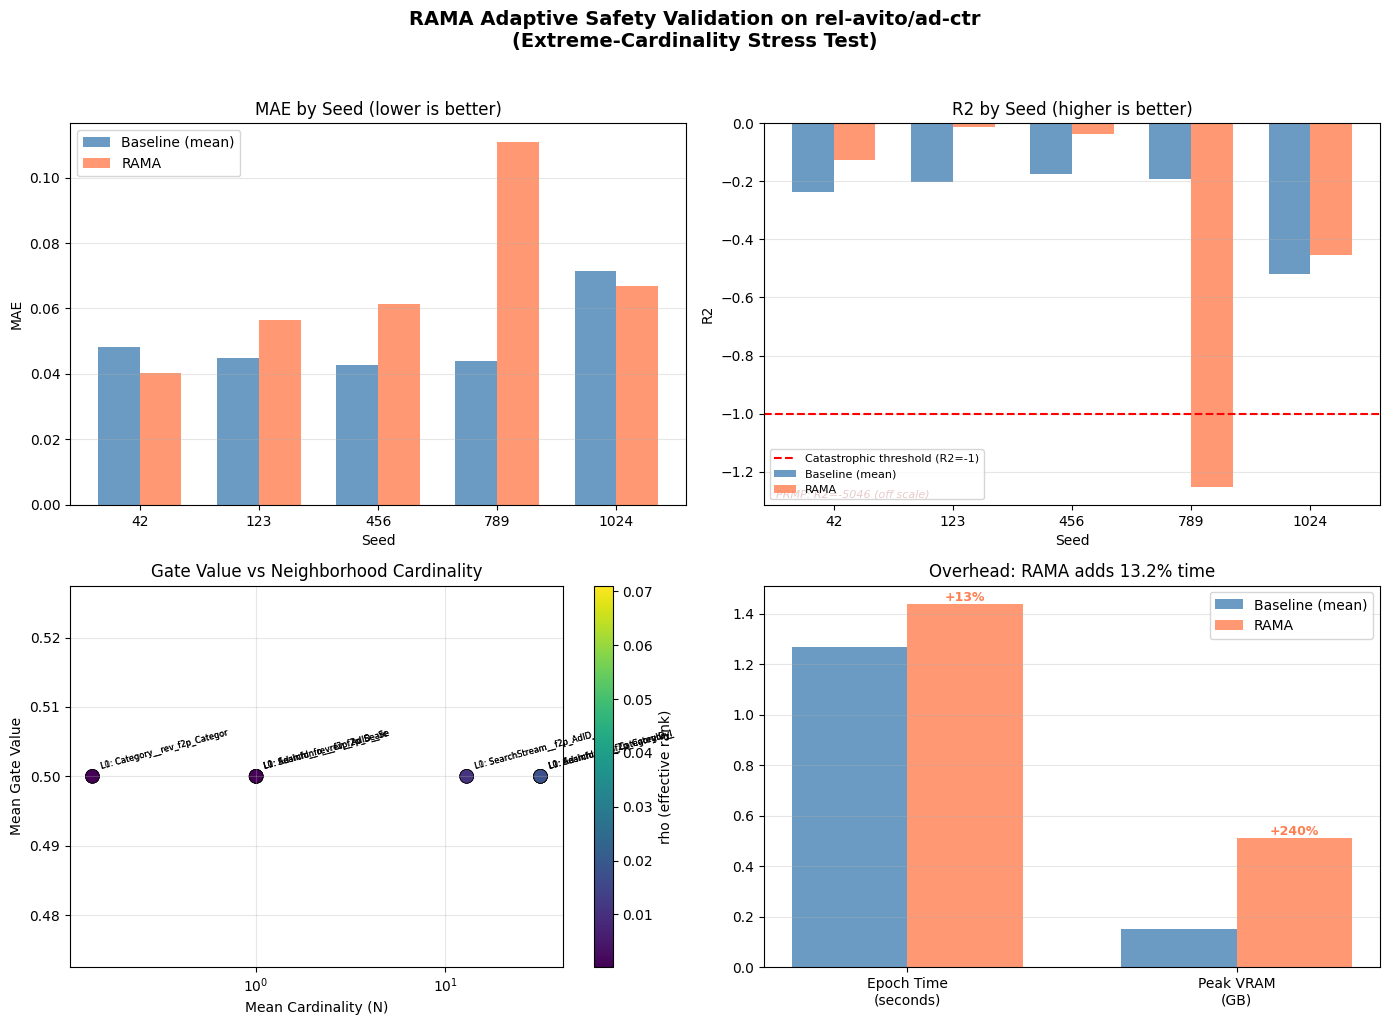

Figure saved to rama_results.png


In [11]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

seeds = [str(s) for s in data['metadata']['seeds']]
seed_labels = [str(s) for s in data['metadata']['seeds']]
x_pos = np.arange(len(seeds))
bar_width = 0.35

# --- Panel 1: MAE per seed ---
ax = axes[0, 0]
b_maes = [baseline_metrics[s]['mae'] for s in seeds]
r_maes = [rama_metrics[s]['mae'] for s in seeds]
ax.bar(x_pos - bar_width/2, b_maes, bar_width, label='Baseline (mean)', color='steelblue', alpha=0.8)
ax.bar(x_pos + bar_width/2, r_maes, bar_width, label='RAMA', color='coral', alpha=0.8)
ax.set_xlabel('Seed')
ax.set_ylabel('MAE')
ax.set_title('MAE by Seed (lower is better)')
ax.set_xticks(x_pos)
ax.set_xticklabels(seed_labels)
ax.legend()
ax.grid(axis='y', alpha=0.3)

# --- Panel 2: R2 per seed ---
ax = axes[0, 1]
b_r2s = [baseline_metrics[s]['r2'] for s in seeds]
r_r2s = [rama_metrics[s]['r2'] for s in seeds]
ax.bar(x_pos - bar_width/2, b_r2s, bar_width, label='Baseline (mean)', color='steelblue', alpha=0.8)
ax.bar(x_pos + bar_width/2, r_r2s, bar_width, label='RAMA', color='coral', alpha=0.8)
ax.axhline(y=-1.0, color='red', linestyle='--', linewidth=1.5, label='Catastrophic threshold (R2=-1)')
ax.annotate('PRMP: R2=-5046 (off scale)', xy=(0.02, 0.02), xycoords='axes fraction',
            fontsize=8, color='darkred', fontstyle='italic')
ax.set_xlabel('Seed')
ax.set_ylabel('R2')
ax.set_title('R2 by Seed (higher is better)')
ax.set_xticks(x_pos)
ax.set_xticklabels(seed_labels)
ax.legend(loc='lower left', fontsize=8)
ax.grid(axis='y', alpha=0.3)

# --- Panel 3: Gate values vs cardinality ---
ax = axes[1, 0]
edge_names_short = []
mean_ns = []
gate_vals_plot = []
rho_vals_plot = []
for et, vals in sorted_edges:
    if vals['mean_N'] > 0:
        parts = et.split('_', 1)
        layer = parts[0]
        rest = parts[1] if len(parts) > 1 else et
        edge_names_short.append(f"{layer}: {rest[:25]}")
        mean_ns.append(vals['mean_N'])
        gate_vals_plot.append(vals['mean_gate'])
        rho_vals_plot.append(vals['mean_rho'])

scatter = ax.scatter(mean_ns, gate_vals_plot, c=rho_vals_plot, cmap='viridis', s=100,
                     edgecolors='black', linewidth=0.5)
for i, name in enumerate(edge_names_short):
    ax.annotate(name, (mean_ns[i], gate_vals_plot[i]), fontsize=6, rotation=15,
                xytext=(5, 5), textcoords='offset points')
ax.set_xlabel('Mean Cardinality (N)')
ax.set_ylabel('Mean Gate Value')
ax.set_title('Gate Value vs Neighborhood Cardinality')
ax.set_xscale('symlog', linthresh=1)
plt.colorbar(scatter, ax=ax, label='rho (effective rank)')
ax.grid(alpha=0.3)

# --- Panel 4: Timing & Memory ---
ax = axes[1, 1]
timing = data['metadata']['timing']
memory = data['metadata']['memory']
categories = ['Epoch Time\n(seconds)', 'Peak VRAM\n(GB)']
baseline_vals_plot = [timing['seconds_per_epoch_baseline'], memory['peak_vram_gb_baseline']]
rama_vals_plot = [timing['seconds_per_epoch_rama'], memory['peak_vram_gb_rama']]
x_cat = np.arange(len(categories))
ax.bar(x_cat - bar_width/2, baseline_vals_plot, bar_width, label='Baseline (mean)', color='steelblue', alpha=0.8)
ax.bar(x_cat + bar_width/2, rama_vals_plot, bar_width, label='RAMA', color='coral', alpha=0.8)
ax.set_xticks(x_cat)
ax.set_xticklabels(categories)
ax.set_title(f'Overhead: RAMA adds {timing["rama_overhead_pct"]:.1f}% time')
ax.legend()
ax.grid(axis='y', alpha=0.3)
for i, (bv, rv) in enumerate(zip(baseline_vals_plot, rama_vals_plot)):
    pct = (rv - bv) / max(bv, 1e-12) * 100
    ax.annotate(f'+{pct:.0f}%', xy=(x_cat[i] + bar_width/2, rv),
                ha='center', va='bottom', fontsize=9, fontweight='bold', color='coral')

plt.suptitle('RAMA Adaptive Safety Validation on rel-avito/ad-ctr\n(Extreme-Cardinality Stress Test)',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('rama_results.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved to rama_results.png")